In [1]:
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 15.9 MB/s eta 0:00:0000:0100:01


In [2]:
!pip install anndata==0.8.0

  Using cached anndata-0.8.0-py3-none-any.whl (96 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 9.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: h5py
    Found existing installation: h5py 2.10.0
    Uninstalling h5py-2.10.0:
      Successfully uninstalled h5py-2.10.0
  Attempting uninstall: anndata
    Found existing installation: anndata 0.7.8
    Uninstalling anndata-0.7.8:
      Successfully uninstalled anndata-0.7.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
samap 1.0.2 requires h5py<=2.10, but you have h5py 3.8.0 which is incompatible.
sam-algorithm 1.0.0 requires h5py<=2.10.0, but you have h5py 3.8.0 which is incompatible.


In [1]:
def inc_edge(G, u, v):
    if G.has_edge(u, v):
        G[u][v]['weight'] += 1
    else:
        G.add_edge(u, v, weight=1)

In [2]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import plotly.express as px
import networkx as nx

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
G = nx.Graph()

In [171]:
sam_cj = SAM()
sam_cj.load_data('Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad')

In [172]:
sam_ac = SAM()
sam_ac.load_data('Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_03122025.h5ad')

In [173]:
sam_xt = SAM()
sam_xt.load_data('Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad')

In [177]:
sam_dr = SAM()
sam_dr.load_data('Active_SAM_joined/SAM_DR_ncbi_NN_geneexp_11202025.h5ad')

In [178]:
level = 'ss_subclass_v2_nounlabeled'

In [184]:
sam_dr.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'eq_subclass', 'eq_subclass_lc',
       'eq_subclass_frac', 'leiden_clusters', 'eq_subclass_nounlabeled',
       'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm',
       'neurotransmitter', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_v2', 'ss_subclass_v2_nounlabeled',
       'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_nounlabeled_nmm_micro', 'ss_subclass_nounlabeled_nmm_v2',
       'ss_subclass_nounlabeled_nmm_v3_nn', 'neurotransmitter_v2'],
      dtype='object')

In [185]:
np.sort(sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique())

array(['010 IT AON-TT-DP Glut', '038 DG-PIR Ex IMN',
       '041 OB-in Frmd7 Gaba', '045 OB-STR-CTX Inh IMN', '053 Sst Gaba',
       '056 Sst Chodl Gaba', '057 NDB-SI-MA-STRv Lhx8 Gaba',
       '061 STR D1 Gaba', '062 STR D2 Gaba', '064 STR-PAL Chst9 Gaba',
       '070 LSX Prdm12 Slit2 Gaba', '075 MEA-BST Lhx6 Nr2e1 Gaba',
       '077 CEA-BST Gal Avp Gaba', '086 MPO-ADP Lhx8 Gaba',
       '089 PVR Six3 Sox3 Gaba', '092 TMv-PMv Tbx3 Hist-Gaba',
       '100 AHN Onecut3 Gaba', '101 ZI Pax6 Gaba',
       '104 TU-ARH Otp Six6 Gaba', '107 DMH Hmx2 Gaba',
       '111 TRS-BAC Sln Glut', '128 VMH Fezf1 Glut', '129 VMH Nr5a1 Glut',
       '131 LHA-AHN-PVH Otp Trh Glut', '132 AHN-RCH-LHA Otp Fezf1 Glut',
       '133 PVH-SO-PVa Otp Glut', '145 MH Tac2 Glut',
       '178 SCig Foxb1 Otx2 Glut', '230 PRNr Otp Nfib Glut',
       '314 CB Granule Glut', 'cj_ac_xt_dr_1', 'cj_ac_xt_dr_2',
       'cj_ac_xt_dr_3', 'cj_ac_xt_dr_4', 'cj_xt_dr_1', 'cj_xt_dr_2',
       'dr_0', 'dr_11', 'dr_12', 'dr_13', 'dr_15'

In [188]:
sam_dr.adata.obs[sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'] == 'dr_3_21_32']['ss_subclass_v2_nounlabeled'].value_counts()

dr_3                      3899
dr_32                      342
010 IT AON-TT-DP Glut        0
dr_16                        0
dr_22                        0
                          ... 
230 PRNr Otp Nfib Glut       0
314 CB Granule Glut          0
dr_0                         0
dr_1                         0
dr_m041_m064                 0
Name: ss_subclass_v2_nounlabeled, Length: 69, dtype: int64

In [176]:
for item in sam_cj.adata.obs[level]:
    if item[:2] == 'cj' and item[3] != 'm':
        G.add_node(item)
        
for item in sam_ac.adata.obs[level]:
    if item[:2] == 'ac'and item[3] != 'm':
        G.add_node(item)

for item in sam_xt.adata.obs[level]:
    if item[:2] == 'xt'and item[3] != 'm':
        G.add_node(item)

for item in sam_dr.adata.obs[level]:
    if item[:2] == 'dr'and item[3] != 'm':
        G.add_node(item)

In [45]:
sam_cj.adata.obs['test'] = pd.read_csv('CJ_ss_subclass_v3_nounlabeled_06182025.csv',index_col = 'Unnamed: 0')
sam_ac.adata.obs['test'] = pd.read_csv('AC_ss_subclass_v3_nounlabeled_06182025.csv',index_col = 'Unnamed: 0')
sam_xt.adata.obs['test'] = pd.read_csv('XT_ss_subclass_v3_nounlabeled_06182025.csv',index_col = 'Unnamed: 0')
sam_dr.adata.obs['test'] = pd.read_csv('DR_ss_subclass_v3_nounlabeled_06182025.csv',index_col = 'Unnamed: 0')

In [138]:
sm = load_samap('Active_SAMap_Joined/active_samap/Non-mammal/sm_xt_dr_ncbi_cleaned_03272025.pkl')

In [140]:
sam_one = sam_xt

In [141]:
sam_two = sam_dr

In [142]:
org_one_saturn = pd.read_csv('SATURN_mapping/zebrafish_XT_ss2_30_seeds.csv', index_col = 'barcode')
org_two_saturn = pd.read_csv('SATURN_mapping/frog_DR_ss2_30_seeds.csv', index_col = 'barcode')

In [143]:
org_one = 'xt'
org_two = 'dr'

In [137]:
sm.sams[org_one].adata.obs

KeyError: 'xt'

In [54]:
#sm.sams[org_one].adata.obs['ss_subclass_v3_nounlabeled'] = pd.read_csv('CJ_ss_subclass_v3_nounlabeled_06182025.csv',index_col = 'Unnamed: 0')

In [55]:
#sm.sams[org_two].adata.obs['ss_subclass_v3_nounlabeled'] = pd.read_csv('AC_ss_subclass_v3_nounlabeled_06182025.csv',index_col = 'Unnamed: 0')

In [144]:
#NN_one = set(sm.sams[org_one].adata.obs[level]) - set(sam_one.adata.obs[level])

In [145]:
#NN_one

{'322 Tanycyte NN',
 '326 OPC NN',
 '327 Oligo NN',
 '330 VLMC NN',
 '333 Endo NN',
 'xt_22',
 'xt_32',
 'xt_40',
 'xt_5'}

In [146]:
#NN_two = set(sm.sams[org_two].adata.obs[level]) - set(sam_two.adata.obs[level])

In [147]:
#NN_two

{'322 Tanycyte NN',
 '323 Ependymal NN',
 '326 OPC NN',
 '327 Oligo NN',
 '328 OEC NN',
 '330 VLMC NN',
 '333 Endo NN',
 '337 DC NN',
 '338 Lymphoid NN',
 'dr_14',
 'dr_21',
 'dr_24',
 'dr_35',
 'dr_37',
 'dr_4'}

In [148]:
keys = {org_one:level,org_two:level}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable =  MappingTable.loc[:,[i for i in MappingTable.columns if i[:2] == org_one]]
lim_MappingTable = lim_MappingTable.loc[[i for i in lim_MappingTable.index if i[:2] == org_two],:]

In [149]:
lim_MappingTable

,xt_009 L2/3 IT PIR-ENTl Glut,xt_011 L2 IT ENT-po Glut,xt_041 OB-in Frmd7 Gaba,xt_054 STR Prox1 Lhx6 Gaba,xt_056 Sst Chodl Gaba,xt_057 NDB-SI-MA-STRv Lhx8 Gaba,xt_058 PAL-STR Gaba-Chol,xt_064 STR-PAL Chst9 Gaba,xt_068 LSX Otx2 Gaba,xt_070 LSX Prdm12 Slit2 Gaba,...,xt_xt_4,xt_xt_40,xt_xt_41,xt_xt_42,xt_xt_5,xt_xt_6,xt_xt_7,xt_xt_8,xt_xt_9,xt_xt_m098_m104
dr_010 IT AON-TT-DP Glut,0.008007,0.001336,0.001054,0.000500,0.000000,0.000000,0.001541,0.001291,0.000000,0.002059,...,0.076174,0.004061,0.000029,0.000000,0.000081,0.008319,0.000143,0.000000,0.017571,0.000000
dr_038 DG-PIR Ex IMN,0.000381,0.018046,0.000000,0.001397,0.000882,0.000074,0.000233,0.000000,0.000877,0.000105,...,0.000087,0.051588,0.018106,0.000000,0.000000,0.000035,0.000845,0.002595,0.001159,0.000000
dr_041 OB-in Frmd7 Gaba,0.000000,0.000089,0.741150,0.001904,0.001927,0.000268,0.000415,0.042680,0.001739,0.011785,...,0.001020,0.000000,0.004303,0.003877,0.000000,0.002094,0.021559,0.000527,0.004000,0.002719
dr_045 OB-STR-CTX Inh IMN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000188,0.000000,0.000000,0.000000,0.000830,...,0.000237,0.000000,0.000000,0.000000,0.000323,0.000321,0.003733,0.000974,0.000177,0.000000
dr_053 Sst Gaba,0.000000,0.000000,0.000000,0.000000,0.000000,0.000507,0.000000,0.000000,0.000000,0.000166,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000698,0.006010,0.000000,0.001850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dr_dr_6,0.000235,0.002089,0.003787,0.087063,0.077759,0.024012,0.064497,0.018292,0.159030,0.161699,...,0.001751,0.000000,0.007646,0.007129,0.000048,0.007649,0.198469,0.003509,0.005653,0.020173
dr_dr_7,0.002586,0.002438,0.000192,0.000000,0.000000,0.000007,0.000000,0.003177,0.000977,0.000610,...,0.097522,0.000009,0.000771,0.000000,0.000075,0.000196,0.004005,0.000511,0.000249,0.000155
dr_dr_8,0.000199,0.001195,0.000699,0.000433,0.000000,0.000165,0.000205,0.058537,0.005211,0.000784,...,0.001207,0.000000,0.000407,0.000000,0.000003,0.004248,0.007873,0.001119,0.004321,0.001664
dr_dr_9,0.000000,0.000000,0.000017,0.000010,0.000000,0.000131,0.000000,0.003970,0.002148,0.001585,...,0.002510,0.000000,0.001356,0.014945,0.000000,0.043020,0.010163,0.001335,0.153167,0.002928


In [150]:
org_one_mapping = {}
for item in sm.sams[org_one].adata.obs[level].unique():
    if item in G and item not in NN_one:
        best_match_samap = lim_MappingTable.loc[:,org_one + '_' + item].idxmax()[3:]
        saturn_vals = org_one_saturn.loc[sm.sams[org_one].adata.obs_names[sm.sams[org_one].adata.obs[level] == item],'seed_0']
        best_match_saturn = org_two + '_' + saturn_vals.mode()[0]
        print(lim_MappingTable.loc[org_two + '_' + best_match_samap,org_one + '_' + item])
        if best_match_samap in G and lim_MappingTable.loc[org_two + '_' + best_match_samap,org_one + '_' + item] > .2:
            inc_edge(G,item,best_match_samap)
        print(np.sum([i == best_match_saturn[3:] for i in saturn_vals])/len(saturn_vals))
        if best_match_saturn in G and np.sum([i == best_match_saturn[3:] for i in saturn_vals])/len(saturn_vals) > .5:
            inc_edge(G,item,best_match_saturn)
        print(item, best_match_saturn, best_match_samap)
        org_one_mapping[item] = [best_match_samap, best_match_saturn, lim_MappingTable.loc[org_two + '_' + best_match_samap,org_one + '_' + item], 
                                 np.sum([i == best_match_saturn[3:] for i in saturn_vals])/len(saturn_vals)]
df = pd.DataFrame.from_dict(org_one_mapping)
df = df.T
df.columns = ['SAMAP match','SATURN match', 'SAMAP score', 'SATURN score']
df.to_csv(org_one + '_' + org_two + '_nonmam_mapping_v2test_07122026.csv')

0.09752225343900114
0.9422776911076443
xt_4 dr_10 dr_7
0.10290885350299132
0.9789029535864979
xt_16 dr_333 Endo NN dr_9
0.14373430979765003
0.39069767441860465
xt_11 dr_34 dr_5
0.24278681470422409
0.7584803256445047
xt_3 dr_21 dr_5
0.10322189798101596
0.70042194092827
xt_15 dr_30 dr_20
0.7407874544679204
0.8597122302158273
xt_13 dr_19 dr_1
0.3176487122400925
0.9601634320735445
xt_0 dr_23 dr_23
0.28645707417183786
0.1728395061728395
xt_12 dr_100 AHN Onecut3 Gaba 101 ZI Pax6 Gaba
0.15316680847699773
0.32723112128146453
xt_9 dr_089 PVR Six3 Sox3 Gaba dr_9
0.3058528642217672
0.8919226393629124
xt_1 dr_29 dr_2
0.19846854979781553
0.7596899224806202
xt_7 dr_070 LSX Prdm12 Slit2 Gaba dr_6
0.09282506685204298
0.24242424242424243
xt_41 dr_314 CB Granule Glut dr_5
0.16379658316245557
0.13
xt_20 dr_323 Ependymal NN 077 CEA-BST Gal Avp Gaba
0.1335700307077748
0.9607843137254902
xt_33 dr_100 AHN Onecut3 Gaba dr_5
0.37746240894720234
0.18867924528301888
xt_25 dr_070 LSX Prdm12 Slit2 Gaba 101 ZI Pax6

In [151]:
org_two_mapping = {}
for item in sm.sams[org_two].adata.obs[level].unique():
    if item in G and item not in NN_two:
        best_match_samap = lim_MappingTable.loc[org_two + '_' + item,:].idxmax()[3:]
        saturn_vals = org_two_saturn.loc[sm.sams[org_two].adata.obs_names[sm.sams[org_two].adata.obs[level] == item],'seed_0']
        best_match_saturn = org_one + '_' + saturn_vals.mode()[0]
        print(lim_MappingTable.loc[org_two + '_' + item,org_one + '_' + best_match_samap])
        if best_match_samap in G and lim_MappingTable.loc[org_two + '_' + item,org_one + '_' + best_match_samap] > .2:
            inc_edge(G,item,best_match_samap)
        print(np.sum([i == best_match_saturn[3:] for i in saturn_vals])/len(saturn_vals))
        if best_match_saturn in G and np.sum([i == best_match_saturn[3:] for i in saturn_vals])/len(saturn_vals) > .5:
            inc_edge(G,item,best_match_saturn)
        print(item, best_match_saturn, best_match_samap)
        org_two_mapping[item] = [best_match_samap, best_match_saturn, lim_MappingTable.loc[org_two + '_' + item,org_one + '_' + best_match_samap], 
                                 np.sum([i == best_match_saturn[3:] for i in saturn_vals])/len(saturn_vals)]
df = pd.DataFrame.from_dict(org_two_mapping)
df = df.T
df.columns = ['SAMAP match','SATURN match', 'SAMAP score', 'SATURN score']
df.to_csv(org_two + '_' + org_one + '_nonmam_mapping_v2test_07122026.csv')

0.35565247700424046
0.9631402584968884
dr_10 xt_4 129 VMH Nr5a1 Glut
0.2391931187726452
0.7102461743180306
dr_6 xt_094 SCH Six6 Cdc14a Gaba xt_21
0.20561006221867953
0.9408262002232973
dr_8 xt_079 CEA-BST Six3 Cyp26b1 Gaba 082 CEA-BST Ebf1 Pdyn Gaba
0.08946477388136549
0.809282700421941
dr_16 xt_181 IC Tfap2d Maf Glut xt_36
0.8960631072750603
0.9975385992392034
dr_1 xt_145 MH Tac2 Glut 145 MH Tac2 Glut
0.5654263428106596
0.8893709327548807
dr_7 xt_17 181 IC Tfap2d Maf Glut
0.4571835638291509
0.809041309431021
dr_15 xt_138 PH Pitx2 Glut 168 SPA-SPFm-SPFp-POL-PIL-PoT Sp9 Glut
0.19619981406302828
0.9915362913567581
dr_3 xt_098 AHN-SBPV-PVHd Pdrm12 Gaba 138 PH Pitx2 Glut
0.3468713522591821
0.9399423026488329
dr_5 xt_2 xt_14
0.12166432690760334
0.9290123456790124
dr_20 xt_262 Pineal Crx Glut 106 PVpo-VMPO-MPN Hmx2 Gaba
0.3058528642217672
0.9935096153846154
dr_2 xt_159 IF-RL-CLI-PAG Foxa1 Glut xt_1
0.20649137494473585
0.5017543859649123
dr_17 xt_073 MEA-BST Sox6 Gaba 073 MEA-BST Sox6 Gaba
0.

In [152]:
m = pd.read_csv('cj_xt_nonmam_mapping_v2test_07122026.csv')
mr = pd.read_csv('xt_cj_nonmam_mapping_v2test_07122026.csv')

In [153]:
m

,Unnamed: 0,SAMAP match,SATURN match,SAMAP score,SATURN score
0,cj_3,xt_3,xt_3,0.259677,0.874336
1,cj_8,xt_25,xt_8,0.095430,0.455696
2,cj_4,xt_21,xt_098 AHN-SBPV-PVHd Pdrm12 Gaba,0.131480,0.887868
3,cj_9,xt_25,xt_277 DTN-LDT-IPN Otp Pax3 Gaba,0.142767,0.731903
4,cj_20,090 BST-MPN Six3 Nrgn Gaba,xt_088 BST Tac2 Gaba,0.112743,0.551867
5,cj_6,xt_30,xt_214 IPN Otp Crisp1 Gaba,0.141900,0.461694
6,cj_7,122 LHA-MEA Otp Glut,xt_140 PMd-LHA Foxb1 Glut,0.165830,0.503480
7,cj_16,xt_7,xt_7,0.517335,0.523810
8,cj_5,xt_18,xt_103 PVHd-DMH Lhx6 Gaba,0.574895,0.659491
9,cj_14,xt_14,xt_14,0.438859,0.584375


In [154]:
list(G.edges(data=True))

[('cj_3', 'ac_0', {'weight': 4}),
 ('cj_3', 'xt_3', {'weight': 4}),
 ('cj_3', 'dr_3', {'weight': 1}),
 ('cj_3', 'dr_32', {'weight': 2}),
 ('cj_8', 'dr_3', {'weight': 1}),
 ('cj_9', 'dr_3', {'weight': 1}),
 ('cj_9', 'dr_34', {'weight': 1}),
 ('cj_6', 'ac_18', {'weight': 4}),
 ('cj_6', 'xt_30', {'weight': 1}),
 ('cj_6', 'dr_26', {'weight': 1}),
 ('cj_16', 'xt_7', {'weight': 3}),
 ('cj_16', 'dr_30', {'weight': 1}),
 ('cj_5', 'xt_18', {'weight': 3}),
 ('cj_14', 'xt_14', {'weight': 4}),
 ('cj_15', 'xt_15', {'weight': 1}),
 ('cj_15', 'dr_19', {'weight': 1}),
 ('cj_21', 'ac_13', {'weight': 4}),
 ('cj_21', 'ac_7', {'weight': 1}),
 ('cj_21', 'xt_36', {'weight': 1}),
 ('cj_21', 'xt_35', {'weight': 1}),
 ('cj_21', 'dr_42', {'weight': 1}),
 ('cj_2', 'ac_3', {'weight': 4}),
 ('cj_2', 'xt_0', {'weight': 3}),
 ('cj_2', 'dr_23', {'weight': 2}),
 ('cj_19', 'dr_26', {'weight': 1}),
 ('cj_27', 'dr_16', {'weight': 1}),
 ('cj_1', 'ac_1', {'weight': 3}),
 ('cj_1', 'ac_24', {'weight': 1}),
 ('cj_1', 'xt_1', 

In [155]:
G_fin = nx.Graph()

In [164]:
for u, v, data in G.edges(data=True):
    if data.get('weight', 0) >= 1:
        #if u[:2] != 'dr' and v[:2] != 'dr':
        G_fin.add_edge(u,v,weight=data['weight'])

In [165]:
list(G_fin.edges(data=True))

[('cj_3', 'ac_0', {'weight': 4}),
 ('cj_3', 'xt_3', {'weight': 4}),
 ('cj_3', 'dr_32', {'weight': 2}),
 ('cj_3', 'dr_3', {'weight': 1}),
 ('ac_0', 'xt_38', {'weight': 3}),
 ('ac_0', 'xt_3', {'weight': 3}),
 ('ac_0', 'dr_3', {'weight': 3}),
 ('ac_0', 'xt_8', {'weight': 1}),
 ('ac_0', 'xt_14', {'weight': 1}),
 ('xt_3', 'dr_5', {'weight': 1}),
 ('cj_6', 'ac_18', {'weight': 4}),
 ('cj_6', 'xt_30', {'weight': 1}),
 ('cj_6', 'dr_26', {'weight': 1}),
 ('cj_16', 'xt_7', {'weight': 3}),
 ('cj_16', 'dr_30', {'weight': 1}),
 ('cj_5', 'xt_18', {'weight': 3}),
 ('cj_14', 'xt_14', {'weight': 4}),
 ('xt_14', 'dr_5', {'weight': 2}),
 ('cj_21', 'ac_13', {'weight': 4}),
 ('cj_21', 'ac_7', {'weight': 1}),
 ('cj_21', 'xt_36', {'weight': 1}),
 ('cj_21', 'xt_35', {'weight': 1}),
 ('cj_21', 'dr_42', {'weight': 1}),
 ('ac_13', 'dr_28', {'weight': 1}),
 ('cj_2', 'ac_3', {'weight': 4}),
 ('cj_2', 'xt_0', {'weight': 3}),
 ('cj_2', 'dr_23', {'weight': 2}),
 ('ac_3', 'xt_0', {'weight': 3}),
 ('ac_3', 'dr_23', {'we

In [166]:
list(G_fin.edges(data=True))

[('cj_3', 'ac_0', {'weight': 4}),
 ('cj_3', 'xt_3', {'weight': 4}),
 ('cj_3', 'dr_32', {'weight': 2}),
 ('cj_3', 'dr_3', {'weight': 1}),
 ('ac_0', 'xt_38', {'weight': 3}),
 ('ac_0', 'xt_3', {'weight': 3}),
 ('ac_0', 'dr_3', {'weight': 3}),
 ('ac_0', 'xt_8', {'weight': 1}),
 ('ac_0', 'xt_14', {'weight': 1}),
 ('xt_3', 'dr_5', {'weight': 1}),
 ('cj_6', 'ac_18', {'weight': 4}),
 ('cj_6', 'xt_30', {'weight': 1}),
 ('cj_6', 'dr_26', {'weight': 1}),
 ('cj_16', 'xt_7', {'weight': 3}),
 ('cj_16', 'dr_30', {'weight': 1}),
 ('cj_5', 'xt_18', {'weight': 3}),
 ('cj_14', 'xt_14', {'weight': 4}),
 ('xt_14', 'dr_5', {'weight': 2}),
 ('cj_21', 'ac_13', {'weight': 4}),
 ('cj_21', 'ac_7', {'weight': 1}),
 ('cj_21', 'xt_36', {'weight': 1}),
 ('cj_21', 'xt_35', {'weight': 1}),
 ('cj_21', 'dr_42', {'weight': 1}),
 ('ac_13', 'dr_28', {'weight': 1}),
 ('cj_2', 'ac_3', {'weight': 4}),
 ('cj_2', 'xt_0', {'weight': 3}),
 ('cj_2', 'dr_23', {'weight': 2}),
 ('ac_3', 'xt_0', {'weight': 3}),
 ('ac_3', 'dr_23', {'we

In [201]:
fin_set = set()
for u,v in G_fin.edges():
    if u[:2] == 'cj':
        fin_set.add(u)
    if v[:2] == 'cj':
        fin_set.add(v)

['blue', 'red', 'red', 'red', 'red', 'blue', 'red', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'blue', 'blue', 'red', 'red', 'red', 'blue', 'blue', 'red', 'red', 'red', 'blue', 'red', 'red', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red']
['cj_3', 'cj_8', 'cj_4', 'cj_9', 'cj_20', 'cj_6', 'cj_7', 'cj_16', 'cj_5', 'cj_14', 'cj_28', 'cj_15', 'cj_25', 'cj_23', 'cj_21', 'cj_2', 'cj_19', 'cj_10', 'cj_27', 'cj_1', 'cj_18', 'cj_35', 'cj_37', 'cj_34', 'cj_26', 'cj_29', 'cj_32', 'cj_11', 'cj_24', 'cj_13', 'cj_12', 'cj_31', 'cj_36', 'cj_38', 'cj_33', 'cj_39']
[565, 395, 544, 373, 241, 496, 431, 273, 511, 320, 129, 317, 171, 188, 203, 797, 242, 370, 133, 1015, 248, 52, 30, 60, 140, 117, 70, 347, 177, 322, 328, 90, 34, 24, 69, 21]


<BarContainer object of 36 artists>

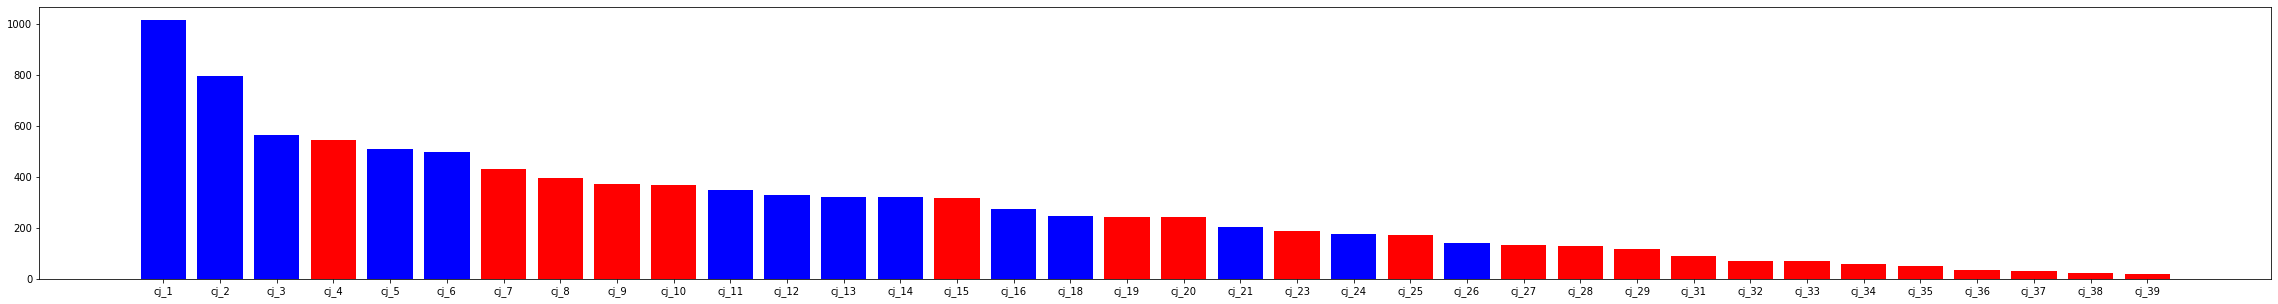

In [202]:
all_len = []
colors = []
xs = []
for item in sam_cj.adata.obs[level].unique():
    if item in G:
        all_len.append(len(sam_cj.adata[sam_cj.adata.obs[level] == item]))
        xs.append(item)
        if item not in fin_set:
            #print(item)
            colors.append('red')
        if item in fin_set:
            #print(item + ' mapped')
            colors.append('blue')
            
sorted_pairs = sorted(zip(all_len,xs,colors), reverse=True)
sorted_values, sorted_names, sorted_colors = zip(*sorted_pairs)

print(colors)
print(xs)
print(all_len)
plt.figure(figsize=(40,5))
plt.bar(x = sorted_names, height = sorted_values, color = sorted_colors)

In [928]:
fin_set = set()
for u,v in G_fin.edges():
    if u[:2] == 'ac':
        fin_set.add(u)
    if v[:2] == 'ac':
        fin_set.add(v)

['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'red', 'red', 'blue', 'red', 'blue', 'blue', 'blue', 'red', 'blue', 'red', 'blue', 'red', 'red', 'red', 'red', 'blue', 'red', 'red', 'red']
['ac_15', 'ac_10', 'ac_0', 'ac_5', 'ac_13', 'ac_3', 'ac_21', 'ac_1_19', 'ac_7_37', 'ac_18', 'ac_34', 'ac_9', 'ac_33', 'ac_28', 'ac_2', 'ac_17_20', 'ac_8_14_23', 'ac_31', 'ac_6', 'ac_39', 'ac_22_26_27', 'ac_11', 'ac_30', 'ac_24', 'ac_29', 'ac_25', 'ac_35', 'ac_32', 'ac_38']
[219, 433, 1809, 602, 271, 692, 128, 1490, 553, 186, 29, 458, 44, 72, 819, 354, 830, 52, 560, 20, 161, 398, 57, 85, 63, 79, 25, 44, 23]


<BarContainer object of 29 artists>

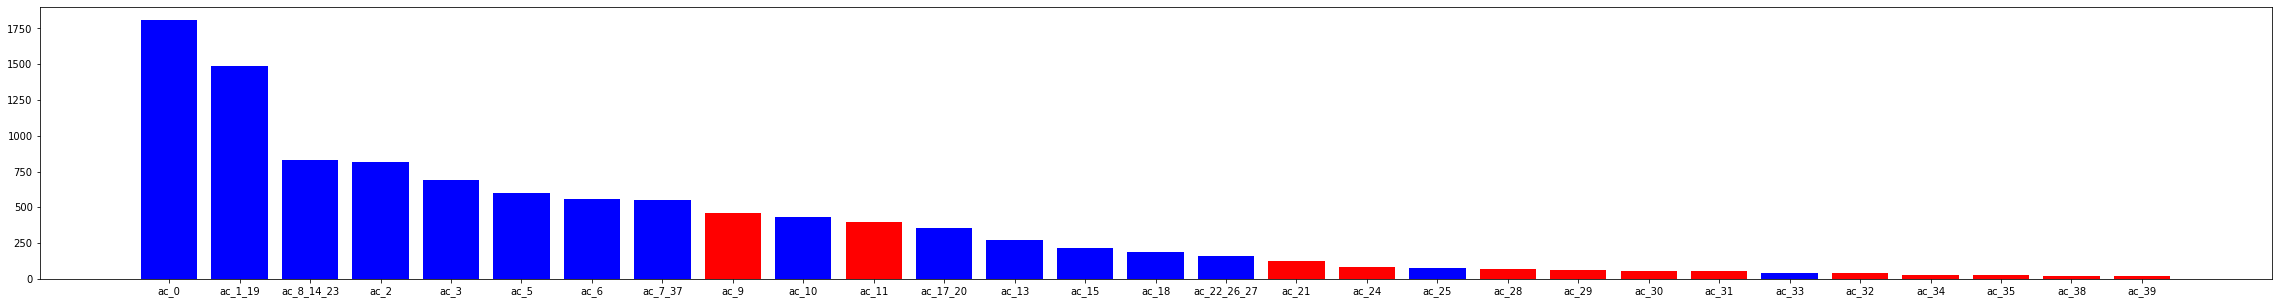

In [929]:
all_len = []
colors = []
xs = []
for item in sam_ac.adata.obs[level].unique():
    if item in G:
        all_len.append(len(sam_ac.adata[sam_ac.adata.obs[level] == item]))
        xs.append(item)
        if item not in fin_set:
            #print(item)
            colors.append('red')
        if item in fin_set:
            #print(item + ' mapped')
            colors.append('blue')
            
sorted_pairs = sorted(zip(all_len,xs,colors), reverse=True)
sorted_values, sorted_names, sorted_colors = zip(*sorted_pairs)

print(colors)
print(xs)
print(all_len)
plt.figure(figsize=(40,5))
plt.bar(x = sorted_names, height = sorted_values, color = sorted_colors)

In [930]:
fin_set = set()
for u,v in G_fin.edges():
    if u[:2] == 'xt':
        fin_set.add(u)
    if v[:2] == 'xt':
        fin_set.add(v)

['blue', 'red', 'red', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'red', 'red', 'red', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'red', 'red', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red']
['xt_4', 'xt_16', 'xt_11', 'xt_3_38', 'xt_15', 'xt_13', 'xt_0', 'xt_12', 'xt_9', 'xt_1', 'xt_7', 'xt_41', 'xt_20', 'xt_33', 'xt_25', 'xt_23', 'xt_8', 'xt_6', 'xt_14', 'xt_31', 'xt_27', 'xt_10', 'xt_18', 'xt_28', 'xt_21', 'xt_29', 'xt_40', 'xt_26', 'xt_17', 'xt_19', 'xt_24', 'xt_30', 'xt_32', 'xt_42', 'xt_39', 'xt_2', 'xt_22', 'xt_37', 'xt_35', 'xt_34', 'xt_36']
[641, 237, 430, 785, 237, 278, 979, 324, 437, 879, 515, 33, 200, 102, 159, 175, 438, 531, 243, 109, 134, 431, 216, 131, 181, 113, 34, 142, 225, 207, 162, 112, 107, 29, 40, 833, 1, 71, 90, 95, 87]


<BarContainer object of 41 artists>

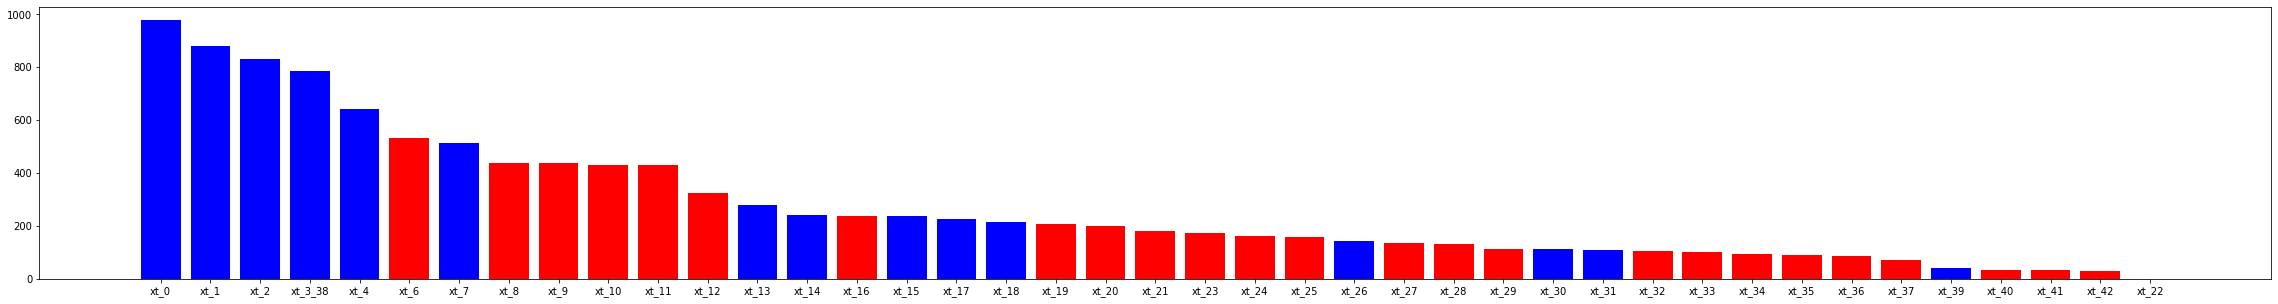

In [931]:
all_len = []
colors = []
xs = []
for item in sam_xt.adata.obs[level].unique():
    if item in G:
        all_len.append(len(sam_xt.adata[sam_xt.adata.obs[level] == item]))
        xs.append(item)
        if item not in fin_set:
            #print(item)
            colors.append('red')
        if item in fin_set:
            #print(item + ' mapped')
            colors.append('blue')
            
sorted_pairs = sorted(zip(all_len,xs,colors), reverse=True)
sorted_values, sorted_names, sorted_colors = zip(*sorted_pairs)

print(colors)
print(xs)
print(all_len)
plt.figure(figsize=(40,5))
plt.bar(x = sorted_names, height = sorted_values, color = sorted_colors)

In [932]:
fin_set = set()
for u,v in G_fin.edges():
    if u[:2] == 'dr':
        fin_set.add(u)
    if v[:2] == 'dr':
        fin_set.add(v)

['blue', 'red', 'red', 'red', 'blue', 'blue', 'red', 'blue', 'red', 'red', 'red', 'red', 'blue', 'red', 'blue', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'blue', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red']
['dr_2_10', 'dr_6', 'dr_8', 'dr_16', 'dr_1', 'dr_22_7', 'dr_15', 'dr_3_21_32', 'dr_5_14', 'dr_20', 'dr_17', 'dr_9', 'dr_13', 'dr_0', 'dr_23', 'dr_18', 'dr_11', 'dr_12', 'dr_19_28', 'dr_31', 'dr_40', 'dr_25', 'dr_39', 'dr_26', 'dr_36', 'dr_33', 'dr_30', 'dr_29', 'dr_41', 'dr_27', 'dr_42', 'dr_38', 'dr_43', 'dr_4', 'dr_34', 'dr_37']
[6249, 3006, 2687, 1185, 4466, 3557, 1283, 4242, 3813, 972, 1139, 2207, 1427, 4533, 712, 1117, 1948, 1772, 1581, 419, 155, 589, 162, 528, 201, 256, 429, 436, 147, 498, 145, 165, 55, 4, 250, 1]


<BarContainer object of 36 artists>

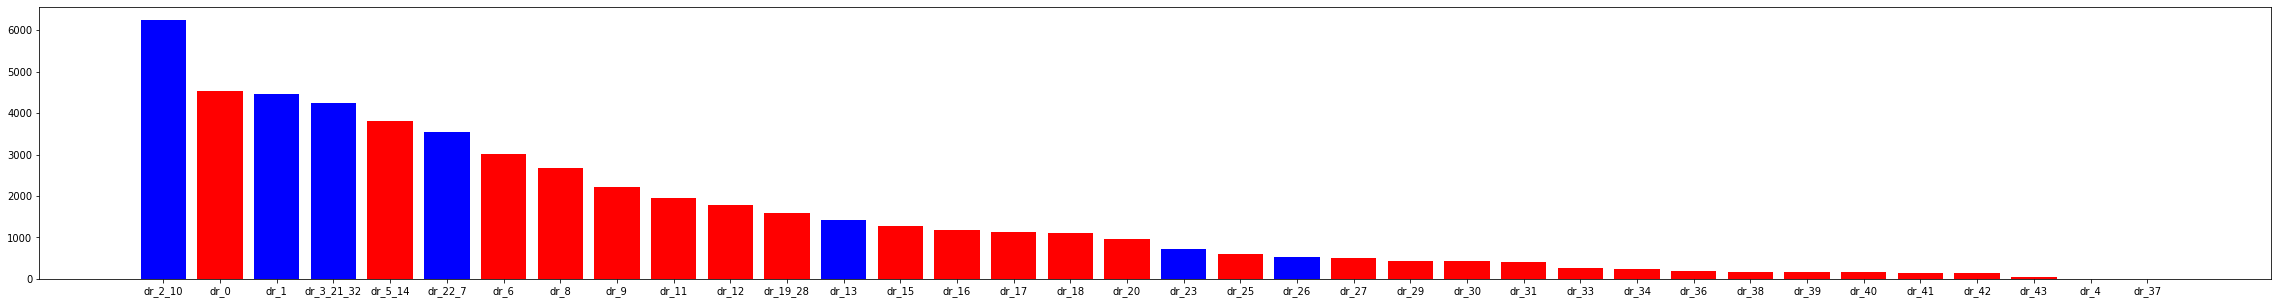

In [933]:
all_len = []
colors = []
xs = []
for item in sam_dr.adata.obs[level].unique():
    if item in G:
        all_len.append(len(sam_dr.adata[sam_dr.adata.obs[level] == item]))
        xs.append(item)
        if item not in fin_set:
            #print(item)
            colors.append('red')
        if item in fin_set:
            #print(item + ' mapped')
            colors.append('blue')
            
sorted_pairs = sorted(zip(all_len,xs,colors), reverse=True)
sorted_values, sorted_names, sorted_colors = zip(*sorted_pairs)

print(colors)
print(xs)
print(all_len)
plt.figure(figsize=(40,5))
plt.bar(x = sorted_names, height = sorted_values, color = sorted_colors)

In [168]:
pos = nx.spring_layout(G_fin, weight='weight', k=.6, iterations =100) 

In [169]:
node_order = list(G_fin.nodes())
colors = []
for item in node_order:
    if item[:2] == 'cj':
        colors.append('red')
    if item[:2] == 'ac':
        colors.append('blue')
    if item[:2] == 'xt':
        colors.append('green')
    if item[:2] == 'dr':
        colors.append('purple')

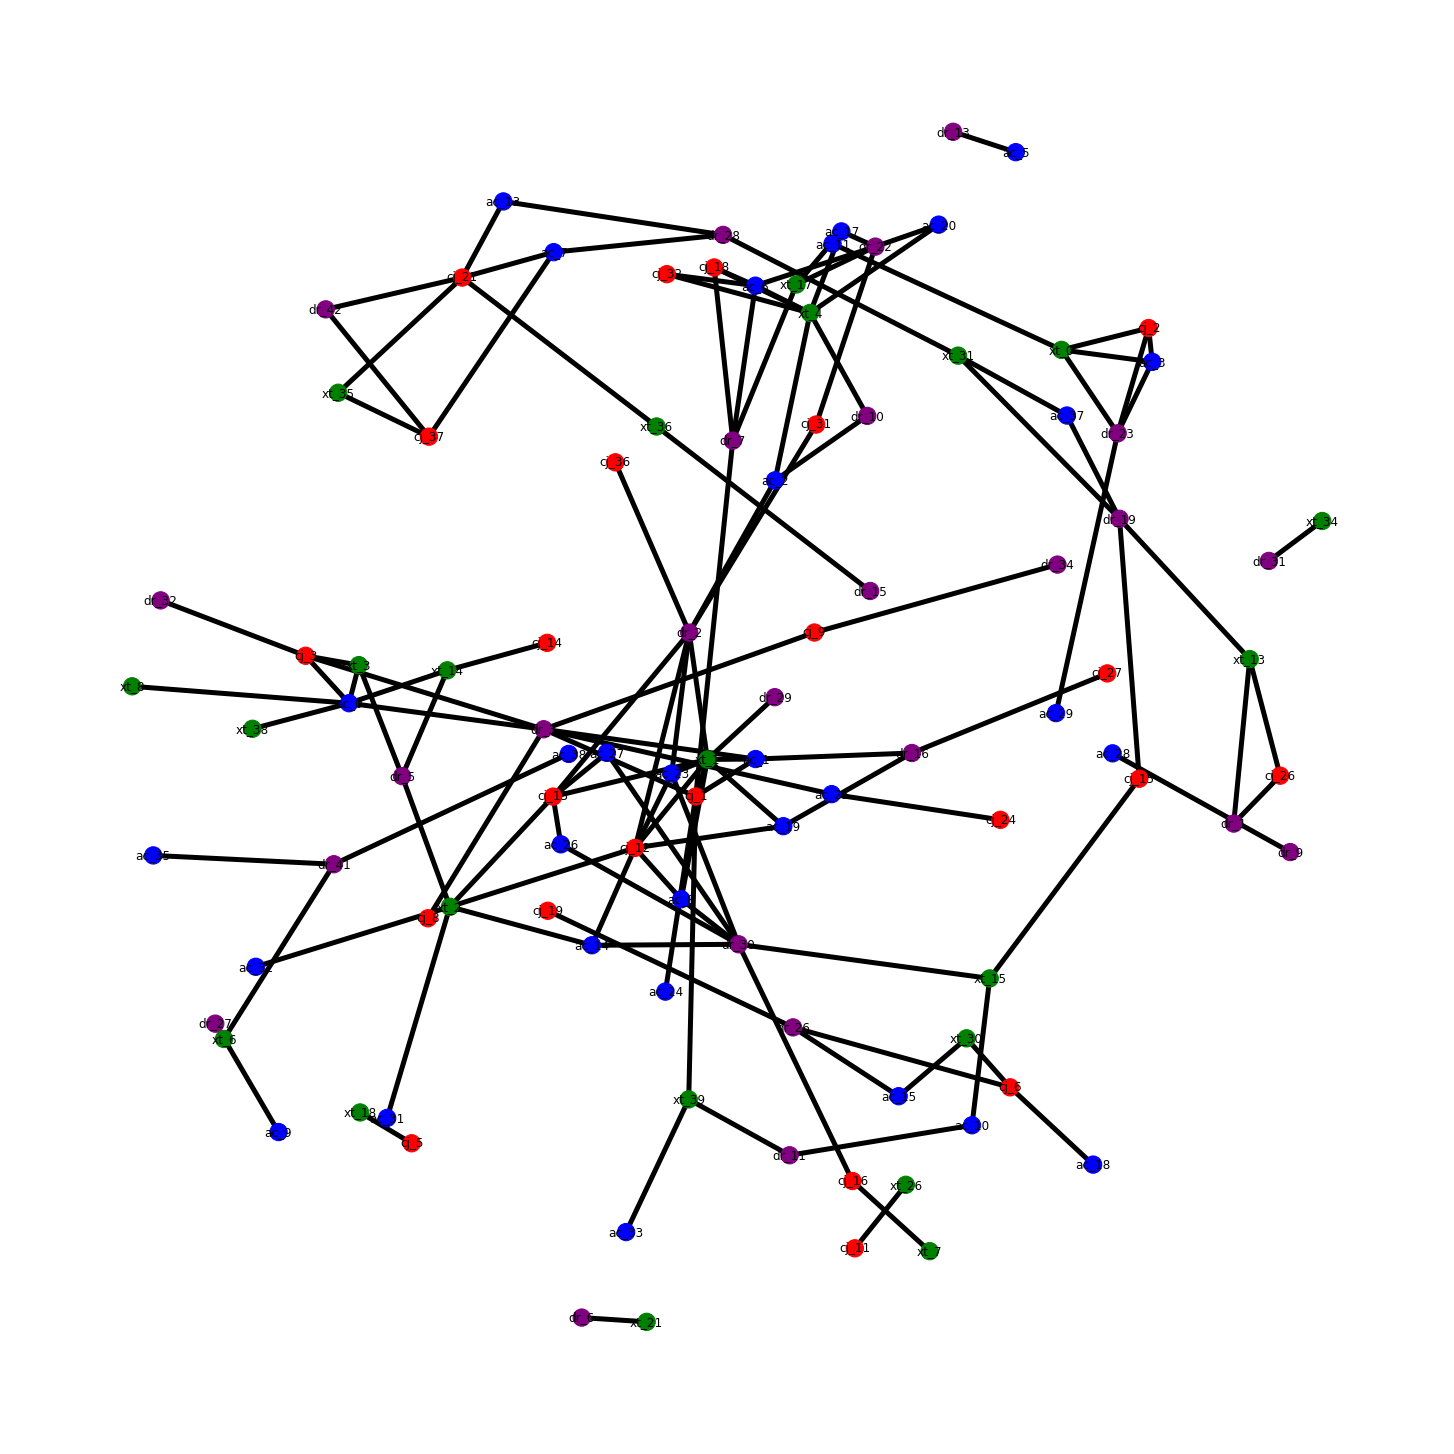

In [170]:
plt.figure(figsize = ((20,20)))
nx.draw(G_fin, pos, with_labels=True,width=5, edge_color='black',node_color = colors)
plt.savefig('nonmam_mappinggraph_v2_testlowerthresh_07120226.svg')
plt.show()

In [206]:
G_fin.remove_edge('xt_2', 'dr_5_14') #XT_14 maps better in both samap and saturn - only saturn believes in XT_2 to dr_5_14
G_fin.remove_edge('xt_1', 'dr_2_10') #Only mapped by SAMAP - maps VERY weakly (JUST ABOVE threshold)
G_fin.remove_edge('dr_22_7','ac_6') #Connects VERY DIFFERENT XT cell types
G_fin.remove_edge('xt_1', 'dr_29') #Connects VERY DIFFERENT DR cell types - SAMAP doesn't like this mapping
G_fin.remove_edge('xt_13', 'dr_19_28') #weakest connection of the group - xt_13 also seems to have a connection to dr_1

In [208]:
components = list(nx.connected_components(G_fin))

In [209]:
components

[{'ac_0', 'cj_3', 'dr_3_21_32', 'xt_3_38'},
 {'ac_18', 'cj_6'},
 {'cj_16', 'xt_7'},
 {'cj_5', 'xt_18'},
 {'cj_14', 'dr_5_14', 'xt_14'},
 {'ac_13', 'cj_21'},
 {'ac_3', 'cj_2', 'dr_23', 'xt_0'},
 {'ac_1_19', 'cj_1', 'dr_16', 'xt_1'},
 {'ac_6', 'cj_18', 'xt_4'},
 {'cj_26', 'dr_1', 'xt_13'},
 {'cj_11', 'xt_26'},
 {'ac_25', 'cj_24'},
 {'ac_22_26_27', 'cj_13', 'xt_2'},
 {'ac_8_14_23', 'cj_12', 'dr_30'},
 {'ac_15', 'dr_26', 'xt_30'},
 {'ac_5', 'dr_13'},
 {'ac_10', 'xt_15'},
 {'ac_7_37', 'dr_19_28', 'xt_31'},
 {'ac_33', 'dr_11', 'xt_39'},
 {'ac_2', 'dr_2_10'},
 {'ac_17_20', 'dr_22_7', 'xt_17'},
 {'dr_29'},
 {'dr_6', 'xt_21'},
 {'dr_31', 'xt_34'}]

In [1329]:
components

[{'ac_0', 'cj_3', 'dr_3_21_32', 'xt_3_38'},
 {'ac_18', 'cj_6'},
 {'cj_16', 'xt_7'},
 {'cj_5', 'xt_18'},
 {'cj_14', 'dr_5_14', 'xt_14'},
 {'ac_13', 'cj_21'},
 {'ac_3', 'cj_2', 'dr_23', 'xt_0'},
 {'ac_1_19', 'cj_1', 'dr_16', 'xt_1'},
 {'ac_6', 'cj_18', 'xt_4'},
 {'cj_26', 'dr_1', 'xt_13'},
 {'cj_11', 'xt_26'},
 {'ac_25', 'cj_24'},
 {'ac_22_26_27', 'cj_13', 'xt_2'},
 {'ac_8_14_23', 'cj_12', 'dr_30'},
 {'ac_15', 'dr_26', 'xt_30'},
 {'ac_10', 'xt_15'},
 {'ac_5', 'dr_13'},
 {'ac_7_37', 'dr_19_28', 'xt_31'},
 {'ac_33', 'dr_11', 'xt_39'},
 {'ac_2', 'dr_2_10'},
 {'ac_17_20', 'dr_22_7', 'xt_17'},
 {'dr_29'},
 {'dr_6', 'xt_21'},
 {'dr_31', 'xt_34'}]

In [210]:
all_mappings = {'cj_ac_xt_dr_1':['ac_0', 'cj_3', 'dr_3_21_32', 'xt_3_38'],
               'cj_ac_1':['ac_18', 'cj_6'],
               'cj_xt_1':['cj_5', 'xt_18'],
               'cj_xt_dr_1':['cj_14', 'dr_5_14', 'xt_14'],
               'cj_ac_xt_dr_2':['ac_1_19', 'cj_1', 'dr_16', 'xt_1'],
               'cj_ac_xt_dr_3':['ac_3', 'cj_2', 'dr_23', 'xt_0'],
               'cj_ac_xt_1':['ac_6', 'cj_18', 'xt_4'],
               'ct_xt_dr_2':['cj_26', 'dr_1', 'xt_13'],
               'cj_xt_2':['cj_11', 'xt_26'],
               'cj_xt_3':['cj_16', 'xt_7'],
               'cj_ac_2':['ac_25', 'cj_24'],
               'cj_ac_3':['ac_13', 'cj_21'],
               'cj_ac_xt_2':['ac_22_26_27', 'cj_13', 'xt_2'],
               'cj_ac_dr_1':['ac_8_14_23', 'cj_12', 'dr_30'],
               'ac_xt_dr_1':['ac_15', 'dr_26', 'xt_30'],
               'ac_xt_1':['ac_10', 'xt_15'],
               'ac_dr_1':['ac_5', 'dr_13'],
               'ac_xt_dr_2':['ac_7_37', 'dr_19_28', 'xt_31'],
               'ac_xt_dr_3':['ac_33', 'dr_11', 'xt_39'],
               'ac_dr_2':['ac_2', 'dr_2_10'],
               'ac_xt_dr_4':['ac_17_20', 'dr_22_7', 'xt_17'],
               'xt_dr_1':['dr_6', 'xt_21'],
               'xt_dr_2':['dr_31', 'xt_34']}

In [211]:
lcomp = []
for item in components:
    lcomp.append(set(item))

In [212]:
lcomp

[{'ac_0', 'cj_3', 'dr_3_21_32', 'xt_3_38'},
 {'ac_18', 'cj_6'},
 {'cj_16', 'xt_7'},
 {'cj_5', 'xt_18'},
 {'cj_14', 'dr_5_14', 'xt_14'},
 {'ac_13', 'cj_21'},
 {'ac_3', 'cj_2', 'dr_23', 'xt_0'},
 {'ac_1_19', 'cj_1', 'dr_16', 'xt_1'},
 {'ac_6', 'cj_18', 'xt_4'},
 {'cj_26', 'dr_1', 'xt_13'},
 {'cj_11', 'xt_26'},
 {'ac_25', 'cj_24'},
 {'ac_22_26_27', 'cj_13', 'xt_2'},
 {'ac_8_14_23', 'cj_12', 'dr_30'},
 {'ac_15', 'dr_26', 'xt_30'},
 {'ac_5', 'dr_13'},
 {'ac_10', 'xt_15'},
 {'ac_7_37', 'dr_19_28', 'xt_31'},
 {'ac_33', 'dr_11', 'xt_39'},
 {'ac_2', 'dr_2_10'},
 {'ac_17_20', 'dr_22_7', 'xt_17'},
 {'dr_29'},
 {'dr_6', 'xt_21'},
 {'dr_31', 'xt_34'}]

In [213]:
set_values = [set(i) for i in all_mappings.values()]

In [214]:
for item in all_mappings.values():
    if set(item) not in lcomp:
        print(item)

In [215]:
for item in lcomp:
    if item not in set_values:
        print(item)

{'dr_29'}


In [216]:
print(len(all_mappings.keys()))

23


In [217]:
print(len(set(all_mappings.keys())))

23


In [218]:
for item in all_mappings.keys():
    if item[:3] == 'cj_':
        print(item)

cj_ac_xt_dr_1
cj_ac_1
cj_xt_1
cj_xt_dr_1
cj_ac_xt_dr_2
cj_ac_xt_dr_3
cj_ac_xt_1
cj_xt_2
cj_xt_3
cj_ac_2
cj_ac_3
cj_ac_xt_2
cj_ac_dr_1


In [219]:
all_mappings_rev = {}
for key, values in all_mappings.items():
    for value in values:
        all_mappings_rev[value] = key 

In [244]:
fn = 'Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad'
sam = SAM()
sam.load_data(fn)

In [247]:
NN_adata = sam.adata[list(set(sam.adata.obs_names) - set(sam_xt.adata.obs_names))]

In [248]:
NN_adata.obs['ss_subclass_v3_nounlabeled'].value_counts()

326 OPC NN         873
322 Tanycyte NN    746
xt_5               611
327 Oligo NN       553
xt_22              176
330 VLMC NN        110
333 Endo NN         62
xt_40               34
Name: ss_subclass_v3_nounlabeled, dtype: int64

In [249]:
fin_labels = []
for item in sam.adata.obs_names:
    if sam.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'] in all_mappings_rev.keys():
        fin_labels.append(all_mappings_rev[sam.adata.obs.loc[item,'ss_subclass_v3_nounlabeled']])
    else:
        fin_labels.append(sam.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'])

In [250]:
sam.adata.obs['ss_subclass_nounlabeled_nmm'] = fin_labels

In [251]:
sam.adata.obs['ss_subclass_nounlabeled_nmm'].unique()

array(['088 BST Tac2 Gaba', '140 PMd-LHA Foxb1 Glut', 'xt_22',
       '141 PH-SUM Foxa1 Glut', '097 PVHd-SBPV Six3 Prox1 Gaba',
       '115 MS-SF Bsx Glut', 'cj_ac_xt_1', 'xt_16', '129 VMH Nr5a1 Glut',
       '101 ZI Pax6 Gaba', '139 PH-LHA Foxb1 Glut',
       '181 IC Tfap2d Maf Glut', 'xt_11', '100 AHN Onecut3 Gaba',
       '322 Tanycyte NN', 'cj_ac_xt_dr_1', '092 TMv-PMv Tbx3 Hist-Gaba',
       'ac_xt_1', '159 IF-RL-CLI-PAG Foxa1 Glut',
       '103 PVHd-DMH Lhx6 Gaba', '102 DMH-LHA Gsx1 Gaba',
       '131 LHA-AHN-PVH Otp Trh Glut', '126 ARH-PVp Tbx3 Glut',
       '118 ADP-MPO Trp73 Glut', '098 AHN-SBPV-PVHd Pdrm12 Gaba',
       '230 PRNr Otp Nfib Glut', '138 PH Pitx2 Glut', '107 DMH Hmx2 Gaba',
       '085 SI-MPO-LPO Lhx8 Gaba', '106 PVpo-VMPO-MPN Hmx2 Gaba',
       'ct_xt_dr_2', '262 Pineal Crx Glut', '327 Oligo NN',
       'cj_ac_xt_dr_3', '215 SNc-VTA-RAmb Foxa1 Dopa', 'xt_12',
       '135 STN-PSTN Pitx2 Glut', '094 SCH Six6 Cdc14a Gaba',
       '104 TU-ARH Otp Six6 Gaba', 'xt_9',

In [252]:
sam.save_anndata(fn)

In [257]:
fin_labels = []
for item in sam_cj.adata.obs_names:
    if sam_cj.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'] in all_mappings_rev.keys():
        fin_labels.append(all_mappings_rev[sam_cj.adata.obs.loc[item,'ss_subclass_v3_nounlabeled']])
    else:
        fin_labels.append(sam_cj.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'])

In [258]:
sam_cj.adata.obs['ss_subclass_nounlabeled_nmm'] = fin_labels

In [259]:
sam_cj.save_anndata('Active_SAM_joined/SAM_CJ_joined_v2_cleaned_geneexp_NN_06192025.h5ad')

In [260]:
fin_labels = []
for item in sam_ac.adata.obs_names:
    if sam_ac.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'] in all_mappings_rev.keys():
        fin_labels.append(all_mappings_rev[sam_ac.adata.obs.loc[item,'ss_subclass_v3_nounlabeled']])
    else:
        fin_labels.append(sam_ac.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'])

In [261]:
sam_ac.adata.obs['ss_subclass_nounlabeled_nmm'] = fin_labels

In [263]:
sam_ac.save_anndata('Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_NN_geneexp_06192025.h5ad')

In [264]:
fin_labels = []
for item in sam_xt.adata.obs_names:
    if sam_xt.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'] in all_mappings_rev.keys():
        fin_labels.append(all_mappings_rev[sam_xt.adata.obs.loc[item,'ss_subclass_v3_nounlabeled']])
    else:
        fin_labels.append(sam_xt.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'])

In [265]:
sam_xt.adata.obs['ss_subclass_nounlabeled_nmm'] = fin_labels

In [267]:
sam_xt.save_anndata('Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_NN_geneexp_06192025.h5ad')

In [268]:
fin_labels = []
for item in sam_dr.adata.obs_names:
    if sam_dr.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'] in all_mappings_rev.keys():
        fin_labels.append(all_mappings_rev[sam_dr.adata.obs.loc[item,'ss_subclass_v3_nounlabeled']])
    else:
        fin_labels.append(sam_dr.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'])

In [269]:
sam_dr.adata.obs['ss_subclass_nounlabeled_nmm'] = fin_labels

In [271]:
sam_dr.save_anndata('Active_SAM_joined/SAM_DR_ncbi_NN_geneexp_06192025.h5ad')

In [990]:
with open('All_nonmammal_mappings_thresh20SAMAP_50SATURN.pkl', 'wb') as f:
    pickle.dump(all_mappings_rev, f)

In [45]:
AC_to_combine = {'ac_8_14_23':['ac_8','ac_14','ac_23'],'ac_1_19':['ac_19','ac_1'],'ac_22_26_27':['ac_22','ac_27','ac_26'], 'ac_7_37':['ac_37','ac_7'],'ac_17_20':['ac_20','ac_17']}
DR_to_combine = {'dr_5_14':['dr_5','dr_14'], 'dr_2_10':['dr_10','dr_2'], 'dr_19_28':['dr_19','dr_28'],'dr_22_7':['dr_22','dr_7'],'dr_3_21_32':['dr_32','dr_21','dr_3']}
XT_to_combine = {'xt_3_38':['xt_3','xt_38']}

In [85]:
AC_combined = {}
for key, values in AC_to_combine.items():
    for value in values:
        AC_combined[value] = key 
        
XT_combined = {}
for key, values in XT_to_combine.items():
    for value in values:
        XT_combined[value] = key 
        
DR_combined = {}
for key, values in DR_to_combine.items():
    for value in values:
        DR_combined[value] = key 
        
CJ_combined = {}

In [86]:
AC_combined

{'ac_8': 'ac_8_14_23',
 'ac_14': 'ac_8_14_23',
 'ac_23': 'ac_8_14_23',
 'ac_19': 'ac_1_19',
 'ac_1': 'ac_1_19',
 'ac_22': 'ac_22_26_27',
 'ac_27': 'ac_22_26_27',
 'ac_26': 'ac_22_26_27',
 'ac_37': 'ac_7_37',
 'ac_7': 'ac_7_37',
 'ac_20': 'ac_17_20',
 'ac_17': 'ac_17_20'}

In [87]:
fin_labels = []
for item in sam_cj.adata.obs['ss_subclass_v2_nounlabeled']:
    if item in CJ_combined:
        fin_labels.append(CJ_combined[item])
    else:
        fin_labels.append(item)
sam_cj.adata.obs['ss_subclass_v3_nounlabeled'] = fin_labels
sam_cj.adata.obs['ss_subclass_v3_nounlabeled'].to_csv('CJ_ss_subclass_v3_nounlabeled_06182025_noNN.csv')

In [88]:
fn = 'Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad'

In [89]:
sam = SAM()
sam.load_data(fn)

In [90]:
fin_labels = []
for item in sam.adata.obs_names:
    if item in sam_cj.adata.obs_names:
        fin_labels.append(sam_cj.adata.obs.loc[item,'ss_subclass_v3_nounlabeled'])
    else:
        fin_labels.append(sam.adata.obs.loc[item,'ss_subclass_v2_nounlabeled'])
sam.adata.obs['ss_subclass_v3_nounlabeled'] = fin_labels
sam.adata.obs['ss_subclass_v3_nounlabeled'].to_csv('CJ_ss_subclass_v3_nounlabeled_06182025.csv')

In [91]:
sam.adata.obs['ss_subclass_v3_nounlabeled'].unique()

array(['085 SI-MPO-LPO Lhx8 Gaba', '327 Oligo NN', '128 VMH Fezf1 Glut',
       '090 BST-MPN Six3 Nrgn Gaba', '129 VMH Nr5a1 Glut',
       '092 TMv-PMv Tbx3 Hist-Gaba', '116 AVPV-MEPO-SFO Tbr1 Glut',
       '106 PVpo-VMPO-MPN Hmx2 Gaba',
       '168 SPA-SPFm-SPFp-POL-PIL-PoT Sp9 Glut', '326 OPC NN',
       '213 SCsg Gabrr2 Gaba', '101 ZI Pax6 Gaba', 'cj_3',
       '089 PVR Six3 Sox3 Gaba', '122 LHA-MEA Otp Glut',
       '126 ARH-PVp Tbx3 Glut', 'cj_8', '111 TRS-BAC Sln Glut', 'cj_4',
       '076 MEA-BST Lhx6 Nfib Gaba', '127 DMH-LHA Vgll2 Glut',
       '135 STN-PSTN Pitx2 Glut', 'cj_9', '102 DMH-LHA Gsx1 Gaba',
       '007 L2/3 IT CTX Glut', 'cj_17', '107 DMH Hmx2 Gaba',
       '086 MPO-ADP Lhx8 Gaba', '100 AHN Onecut3 Gaba',
       '141 PH-SUM Foxa1 Glut', '057 NDB-SI-MA-STRv Lhx8 Gaba', 'cj_20',
       '118 ADP-MPO Trp73 Glut', '125 DMH Hmx2 Glut',
       '132 AHN-RCH-LHA Otp Fezf1 Glut', 'cj_6', '109 LGv-ZI Otx2 Gaba',
       '070 LSX Prdm12 Slit2 Gaba', '069 LSX Nkx2-1 Gaba',
     

In [92]:
NN_adata = sam.adata[list(set(sam.adata.obs_names) - set(sam_cj.adata.obs_names))]

In [93]:
NN_adata.obs['ss_subclass_v3_nounlabeled'].value_counts()

327 Oligo NN             9155
cj_0                     4673
326 OPC NN               2292
322 Tanycyte NN           559
319 Astro-TE NN           466
323 Ependymal NN          284
330 VLMC NN               282
334 Microglia NN          265
cj_17                     263
321 Astroependymal NN     220
cj_22                     189
329 ABC NN                149
cj_30                     101
333 Endo NN                38
332 SMC NN                 37
325 CHOR NN                28
Name: ss_subclass_v3_nounlabeled, dtype: int64

In [94]:
sam.save_anndata(fn)

In [684]:
saturn = pd.read_csv('SATURN_mapping/anolis_DR_ss2_30_seeds.csv', index_col = 'barcode')

In [685]:
fin_labels = []
for item in saturn.index:
    if 'ac_' + saturn.loc[item,'seed_0'] in AC_combined:
        fin_labels.append(AC_combined['ac_' + saturn.loc[item,'seed_0']][3:])
    else:
        fin_labels.append(saturn.loc[item,'seed_0'])

In [686]:
df = pd.DataFrame(data=fin_labels,index=saturn.index,columns = ['seed_0'])

In [687]:
df['seed_0'].unique()

array(['4', '12', '061 STR D1 Gaba', '327 Oligo NN', '333 Endo NN',
       '070 LSX Prdm12 Slit2 Gaba', '062 STR D2 Gaba', '335 BAM NN',
       '069 LSX Nkx2-1 Gaba', '326 OPC NN', '330 VLMC NN', '1_19',
       '216 MB-MY Tph2 Glut-Sero', '322 Tanycyte NN',
       '079 CEA-BST Six3 Cyp26b1 Gaba', '057 NDB-SI-MA-STRv Lhx8 Gaba',
       '093 RT-ZI Gnb3 Gaba', '168 SPA-SPFm-SPFp-POL-PIL-PoT Sp9 Glut',
       '9', '140 PMd-LHA Foxb1 Glut', '0', '213 SCsg Gabrr2 Gaba',
       '085 SI-MPO-LPO Lhx8 Gaba', 'm138', '106 PVpo-VMPO-MPN Hmx2 Gaba',
       '16', '2', '101 ZI Pax6 Gaba', '039 OB Meis2 Thsd7b Gaba', '10',
       '141 PH-SUM Foxa1 Glut', '28', '329 ABC NN', '129 VMH Nr5a1 Glut',
       '25', '109 LGv-ZI Otx2 Gaba', '319 Astro-TE NN',
       '133 PVH-SO-PVa Otp Glut', '104 TU-ARH Otp Six6 Gaba',
       '132 AHN-RCH-LHA Otp Fezf1 Glut', '36', '118 ADP-MPO Trp73 Glut',
       '7_37', '064 STR-PAL Chst9 Gaba', '116 AVPV-MEPO-SFO Tbr1 Glut',
       '127 DMH-LHA Vgll2 Glut', '092 TMv-PMv Tb

In [688]:
df.to_csv('SATURN_mapping/anolis_DR_ss3_30_seeds.csv')

In [693]:
sam_ac.save_anndata('Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_NN_geneexp_04292025.h5ad')

In [696]:
sam_xt.save_anndata('Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_NN_geneexp_04292025.h5ad')

In [698]:
sam_dr.save_anndata('Active_SAM_joined/SAM_DR_ncbi_NN_geneexp_04292025.h5ad')

In [708]:
sam = SAM()
sam.load_data('Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad')

In [711]:
sam.adata.obs['ss_subclass_v2_nounlabeled'].to_csv('CJ_ss_subclass_v3_nounlabeled.csv')